In [ ]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

# LangGraph Parallel Agent

**LangChain 3.x 환경 설정**  

In [ ]:
# !pip install --prefer-binary langgraph==0.4.0 langchain-openai==0.3.33 langchain-community==0.3.30  -q
# !pip install --no-deps "langchain-teddynote==0.3.42" -q
!pip install langgraph langchain-openai langchain-community  -q
!pip install langchain-teddynote -q
# google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
import os
from google.colab import userdata

# OpenAI API 키는 필요시 설정 (이번 실습에서는 사용하지 않음)
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

#### Graph 시각화 : 환경에 따라 선택적으로 사용     
1. IPython.display 사용 : 외부 서버(mermaid)를 통해 image 생성 함  
2. langchain_teddynote.graphs

In [ ]:
# # ## Ipython.disply
# !pip install nest_asyncio   # Jupyter Notebook에서 비동기 실행을 위해 필요
# from IPython.display import Image, display
# import nest_asyncio
# nest_asyncio.apply()
# # Mermaid 서버에 접속(https://mermaid.live)하여 처리함(사내에서 안될수도 있음)
# display(Image(app.get_graph().draw_mermaid_png()))
# print(app.get_graph().draw_mermaid()) # site에 접속해서 그릴 경우

## langchain_teddynote
from langchain_teddynote.graphs import visualize_graph

## Tool 정의

In [ ]:
import json

# 가상 DB 역할을 하는 딕셔너리
mock_process_db = {
    "포토리소그래피": json.dumps({"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}),
    "식각": json.dumps({"RF_Power (W)": 500, "Pressure (mTorr)": 10, "Validated": "Yes"})
}

def get_process_data(step_name: str) -> str:
    """DB에서 공정 데이터를 조회하는 툴"""
    print(f"--- TOOL: get_process_data(step_name='{step_name}') 실행 ---")
    return mock_process_db.get(step_name, "해당 공정 데이터를 찾을 수 없습니다.")

# 가상 매뉴얼 파일 생성
with open("DUV_manual.txt", "w", encoding="utf-8") as f:
    f.write("DUV 공정의 핵심은 193nm 파장의 빛을 사용하여 미세 패턴을 형성하는 것입니다.")

def load_manual(path: str) -> str:
    """매뉴얼 파일을 로딩하는 툴"""
    print(f"--- TOOL: load_manual(path='{path}') 실행 ---")
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        return f"파일을 찾을 수 없습니다: {path}"

## Graph Workflow 뼈대   
> 가장 기본적인 '계획(Plan) -> 실행(Execute)' 흐름을 가진 2단계 그래프




### Graph State 및 Node 정의  
> LangGraph의 모든 노드는 상태(State) 객체를 공유하며 정보를 주고받음   
이 상태의 구조를 정의하고,
각 상태를 변화시키는 함수(노드)들을 정의 함  

In [ ]:
from typing import TypedDict, Annotated, List
from langchain_openai import ChatOpenAI

## 그래프의 상태 정의
# 각 노드를 거치면서 이 상태 객체의 값들이 변경
class AgentState(TypedDict):
    query: str             # 사용자의 원본 질문
    plan: List[str]        # LLM이 생성한 실행 계획
    tool_results: List[str]# 각 도구의 실행 결과
    final_answer: str      # 최종 답변

## LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 각 노드가 될 함수들 정의
# 쿼리를 바탕으로 실행 계획 생성
def planner_node(state: AgentState) -> dict:
    print("---노드 실행: planner_node ---")
    query = state['query']   # 사용자의 원본 질문

    # 예시를 위해 고정된 계획 생성, 앞에서는 LLM으로 구현
    if "포토리소그래피" in query:
        plan = ["DB_QUERY:포토리소그래피"] * 2
    else:
        plan = [f"LLM_CALL:{query}"]

    print(f"생성된 계획: {plan}")
    return {"plan": plan}   # state update

# 계획에 따라 도구를 실행
def executor_node(state: AgentState) -> dict:
    print("--- 노드 실행: executor_node ---")
    results = []
    for step in state['plan']:
        if step.startswith("DB_QUERY:"): # str이 "--"로 시작되는가?
            _, step_name = step.split(":", 1)  # "포토리소그래피"
            results.append(get_process_data(step_name)) # "DB_QUERY"실행
        else: # LLM_CALL 또는 기타
             _, prompt = step.split(":", 1)
             # 실제로는 여기서 LLM을 호출해야 하지만, 예제 단순화를 위해 문자열을 반환
             results.append(f"'{prompt}'에 대한 설명을 생성했습니다.")
    return {"tool_results": results}

### 그래프 구성 및 실행  
> 정의한 상태와 노드들을 StateGraph에 추가하고,  
엣지로 연결하여 워크플로우를 완성

In [ ]:
from langgraph.graph import StateGraph, END

# 그래프 워크플로우 정의
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("planner", planner_node)
workflow.add_node("executor", executor_node)

# 엣지 추가 (어떤 노드 다음에 어떤 노드가 실행될지)
workflow.set_entry_point("planner") # 시작점 지정
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", END) # 끝점 지정

# 그래프 컴파일
app = workflow.compile()

In [ ]:
visualize_graph(app)

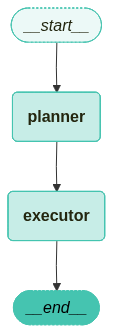

In [ ]:
## 전체 실행 후 결과 확인
final_state = app.invoke({"query": "포토리소그래피 파라미터 알려줘"})

print("\n--- 최종 실행 결과 ---")
print(final_state['tool_results'])

---노드 실행: planner_node ---
생성된 계획: ['DB_QUERY:포토리소그래피', 'DB_QUERY:포토리소그래피']
--- 노드 실행: executor_node ---
--- TOOL: get_process_data(step_name='포토리소그래피') 실행 ---
--- TOOL: get_process_data(step_name='포토리소그래피') 실행 ---

--- 최종 실행 결과 ---
['{"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}', '{"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}']


In [ ]:
## 단계별로 실행 결과 검토 : 실행 및 결과 확인
input_data = {"query": "포토리소그래피 파라미터 알려줘"}
for event in app.stream(input_data):
    print(f"event:{event}")
    for key, value in event.items():  # node return {key,value}
        print(f"--- 스트림 이벤트: 노드 '{key}' 실행 완료 ---")
        print(value,'\n')

---노드 실행: planner_node ---
생성된 계획: ['DB_QUERY:포토리소그래피', 'DB_QUERY:포토리소그래피']
event:{'planner': {'plan': ['DB_QUERY:포토리소그래피', 'DB_QUERY:포토리소그래피']}}
--- 스트림 이벤트: 노드 'planner' 실행 완료 ---
{'plan': ['DB_QUERY:포토리소그래피', 'DB_QUERY:포토리소그래피']} 

--- 노드 실행: executor_node ---
--- TOOL: get_process_data(step_name='포토리소그래피') 실행 ---
--- TOOL: get_process_data(step_name='포토리소그래피') 실행 ---
event:{'executor': {'tool_results': ['{"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}', '{"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}']}}
--- 스트림 이벤트: 노드 'executor' 실행 완료 ---
{'tool_results': ['{"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}', '{"Dose (mJ/cm^2)": 25.0, "Focus (um)": -0.05, "Validated": "Yes"}']} 



## 병렬 분기 및 결과 병합  
### 하나의 입력에 대해 DB 조회와 매뉴얼 로딩을 동시에 실행하고, 그 결과 합치기  


### 병렬 처리용 노드 정의



In [ ]:
# 병렬 처리를 위한 새로운 상태 정의
class ParallelState(TypedDict):
    query: str
    db_result: str
    manual_result: str
    final_summary: str

# 각자 다른 작업을 수행하는 병렬 노드들
def db_node(state: ParallelState) -> dict:
    print("--- 노드 실행: db_node ---")
    return {"db_result": get_process_data(state['query'])}

def manual_node(state: ParallelState) -> dict:
    print("--- 노드 실행: manual_node ---")
    # 실제로는 쿼리에서 파일명을 추출해야 하지만, 예제 단순화를 위해 고정
    return {"manual_result": load_manual("DUV_manual.txt")}

# 병렬 노드들의 결과를 종합하여 최종 답변 생성
def merge_node(state: ParallelState) -> dict:
    print("--- 노드 실행: merge_node ---")
    prompt = f"""
다음 두 가지 정보를 종합하여 사용자의 질문에 대한 최종 요약 답변을 생성해주세요.
질문: {state['query']}에 대한 정보 요약

DB 정보: {state['db_result']}
매뉴얼 정보: {state['manual_result']}

종합 요약:
"""
    summary = llm.invoke(prompt).content
    return {"final_summary": summary}

### 병렬 그래프 구성 및 실행
>add_edge를 사용하여 한 노드에서 여러 노드로 엣지를 연결하면,   
해당 노드들이 병렬로 실행

In [ ]:
# 새로운 병렬 그래프 정의
parallel_workflow = StateGraph(ParallelState)

# 시작점으로 사용할 더미 노드 (입력을 받아서 분기로 전달)
parallel_workflow.set_entry_point("start")
parallel_workflow.add_node("start", lambda state: {})# dummy node 꼭 필요함

# 병렬로 실행될 노드들 추가
parallel_workflow.add_node("db_task", db_node)
parallel_workflow.add_node("manual_task", manual_node)

# 결과 병합 노드 추가
parallel_workflow.add_node("merge_results", merge_node)

# 엣지 연결
parallel_workflow.add_edge("start", "db_task")       # start -> db_task
parallel_workflow.add_edge("start", "manual_task")   # start -> manual_task
parallel_workflow.add_edge("db_task", "merge_results")    # db_task -> merge_results
parallel_workflow.add_edge("manual_task", "merge_results")# manual_task가 -> merge_results

# 병합 노드 이후 종료
parallel_workflow.add_edge("merge_results", END)
# 컴파일 및 실행
parallel_app = parallel_workflow.compile()



In [ ]:
visualize_graph(parallel_app)

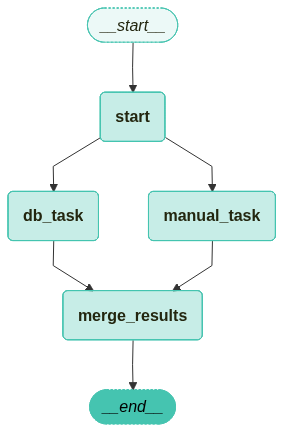

In [ ]:
final_state = parallel_app.invoke({"query": "포토리소그래피"})

print("\n--- 최종 실행 결과 ---")
print(final_state['final_summary'])

--- 노드 실행: db_node ---
--- TOOL: get_process_data(step_name='포토리소그래피') 실행 ---
--- 노드 실행: manual_node ---
--- TOOL: load_manual(path='DUV_manual.txt') 실행 ---
--- 노드 실행: merge_node ---

--- 최종 실행 결과 ---
포토리소그래피는 DUV 공정에서 193nm 파장의 빛을 사용하여 미세 패턴을 형성하는 기술입니다. 이 과정에서 필요한 광량은 25.0 mJ/cm²이며, 초점은 -0.05μm로 설정됩니다. 이 정보는 검증된 데이터입니다.


## Error 처리 추가  
### DB 조회 시, 찾는 데이터가 없으면 오류가 발생했다고 가정하고,이 때 LLM을 호출하여 대안적인 설명을 생성하는 분기 생성  
> DB 조회 결과에 'error'가 포함되어 있는지 여부에 따라, 정상적으로 종료하거나 '오류 처리 노드'로 분기하도록 조건부 엣지(add_conditional_edges)를 추가하자  

### 조건부 분기 그래프  
> add_conditional_edges는 특정 함수의 반환값에 따라 다음에 실행될 노드를 동적으로 결정

In [ ]:
# 조건부 분기를 위한 상태 및 노드 정의
class ConditionalState(TypedDict):
    query: str
    result: str

# DB를 조회하고, 결과가 없을 경우 'error'를 포함한 결과를 반환
def conditional_db_node(state: ConditionalState) -> dict:
    print("--- 노드 실행: conditional_db_node ---")
    query = state['query']
    result = get_process_data(query) # 없는 데이터를 조회하면 에러 문자열이 포함됨
    return {"result": result}

# 오류 발생 시 LLM을 호출하여 대안적인 답변을 생성
def fallback_node(state: ConditionalState) -> dict:
    print("--- 노드 실행: fallback_node (오류 처리) ---")
    query = state['query']
    error_message = state['result']
    prompt = f"'{query}'에 대한 데이터를 찾을 수 없습니다 ({error_message}). 대신 '{query}'가 무엇인지 일반적인 지식을 바탕으로 한줄로 설명해주세요."
    fallback_answer = llm.invoke(prompt).content
    return {"result": fallback_answer}

# 분기 조건을 결정하는 함수
# state의 result 값에 'error'가 포함되어 있는지 확인하여 분기 경로를 반환
def should_fallback(state: ConditionalState) -> str:
    print("--- 조건 확인: should_fallback ---")
    if "error" in state.get("result", "") or "찾을 수 없습니다" in state.get("result", ""):
        print("-> 분기: fallback_node로 이동")
        return "fallback" # conditional_edges()에서 참조할 이름
    else:
        print("-> 분기: 정상 종료")
        return "end"      # conditional_edges()에서 참조할 이름

In [ ]:
# 조건부 그래프 구성
conditional_workflow = StateGraph(ConditionalState)

conditional_workflow.set_entry_point("db_query")
conditional_workflow.add_node("db_query", conditional_db_node)
conditional_workflow.add_node("fallback", fallback_node)

# 조건부 엣지 추가
conditional_workflow.add_conditional_edges(
    "db_query",           # 이 노드 실행 후에 조건을 검사
    should_fallback,      # 어떤 경로로 갈지 결정하는 함수
    {
        "fallback": "fallback", # 'fallback'을 반환하면 fallback 노드로 이동
        "end": END              # 'end'를 반환하면 그래프 종료
    }
)
# fallback 노드 실행 후에는 무조건 종료
conditional_workflow.add_edge("fallback", END)

# 컴파일
conditional_app = conditional_workflow.compile()

visualize_graph(conditional_app)

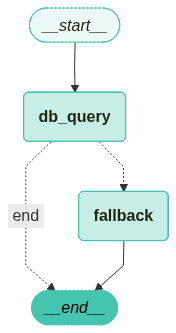

In [ ]:
# --- 검증 ---
print("--- 검증: 정상 실행 케이스 ---")
# DB에 존재하는 데이터 조회
normal_result = conditional_app.invoke({"query": "식각"})
print("\n[최종 결과]")
print(normal_result['result'])

--- 검증: 정상 실행 케이스 ---
--- 노드 실행: conditional_db_node ---
--- TOOL: get_process_data(step_name='식각') 실행 ---
--- 조건 확인: should_fallback ---
-> 분기: 정상 종료

[최종 결과]
{"RF_Power (W)": 500, "Pressure (mTorr)": 10, "Validated": "Yes"}


In [ ]:
print("\n\n--- 검증: 오류 분기 케이스 ---")
# DB에 존재하지 않는 데이터 조회
error_result = conditional_app.invoke({"query": "붕어빵 레시피"})
print("\n[최종 결과]")
print(error_result['result'])



--- 검증: 오류 분기 케이스 ---
--- 노드 실행: conditional_db_node ---
--- TOOL: get_process_data(step_name='붕어빵 레시피') 실행 ---
--- 조건 확인: should_fallback ---
-> 분기: fallback_node로 이동
--- 노드 실행: fallback_node (오류 처리) ---

[최종 결과]
붕어빵은 밀가루 반죽에 팥소나 크림 등을 채워 붕어 모양으로 구운 한국의 전통 간식입니다.
